In [29]:
import pandas as pd
import numpy as np

df = pd.read_parquet("../data/data.parquet")

print(df.shape)
df.head()

(752856, 101)


,date,ticker,price,beta_1y,alpha_1y,sector,log_market_cap,pe,future_ret_1d,future_ret_1w,...,drawdown_rel_1y,drawdown_rel_5y,excess_vs_market_1y,trend_vs_market_1y,risk_adjusted_1y,risk_adjusted_5y,sector_is_strong,sector_is_trending,sector_high_breadth,quality_score
0,2016-06-29,FXY,94.019997,-0.627880,0.005701,Unknown,19.076858,NaN,-0.004680,0.020634,...,0.092119,-0.006531,0.209276,0.000856,1.004770,-0.514267,False,False,False,3
1,2016-07-07,FXY,95.959999,-0.620811,0.005659,Unknown,19.097282,NaN,0.003126,-0.043664,...,0.101530,0.010638,0.185648,0.000853,0.823611,-0.515324,True,False,False,3
2,2016-07-14,FXY,91.769997,-0.615202,-0.008214,Unknown,19.052636,NaN,-0.001634,-0.003705,...,0.048909,-0.024675,0.146197,0.000807,0.594796,-0.586706,True,False,True,3
3,2016-07-21,FXY,91.430000,-0.617343,0.012402,Unknown,19.048924,NaN,-0.004375,0.002953,...,0.041489,-0.032455,0.111604,0.000746,0.452209,-0.628255,True,True,False,3
4,2016-07-28,FXY,91.699997,-0.619016,-0.000872,Unknown,19.051873,NaN,0.032824,0.041767,...,0.048050,-0.027455,0.106656,0.000694,0.502994,-0.640150,True,True,False,3


In [30]:
# Missing Data
missing = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Percent": df.isna().mean() * 100
})

missing = missing[missing["Missing"] > 0]
print( missing.sort_values("Percent", ascending=False) )

missing_mc = df[df["log_market_cap"].isna()]

miss = df[df["log_market_cap"].isna()]["ticker"].nunique()
total = df["ticker"].nunique()
print(f"\nMissing market cap tickers: {miss}/{total} ({miss/total:.2%})")

missing_tickers = missing_mc["ticker"].unique()

print(
    df[df["ticker"].isin(missing_tickers)][["ticker","sector"]]
    .drop_duplicates()
)

                Missing    Percent
pe               166487  22.114056
log_market_cap    22083   2.933230

Missing market cap tickers: 89/3026 (2.94%)
       ticker              sector
724     FNMAP  Financial Services
1664     SVXY             Unknown
5126     SOYB             Unknown
13709    GORO             Unknown
18330     FXB             Unknown
...       ...                 ...
672921    DDT             Unknown
709558    PYT             Unknown
724121    YCL             Unknown
751591   GSCE             Unknown
752097    JBK             Unknown

[89 rows x 2 columns]


In [31]:
# Blank Data
string_cols = df.select_dtypes(include=["object", "string"]).columns
blank_found = 0

for col in string_cols:
    blanks = (df[col].astype(str).str.strip() == "").sum()
    if blanks:
        print(f"{col}: {blanks:,} blank values")
        blank_found += 1

print( f"{blank_found} blanks found.")

0 blanks found.


In [32]:
#Infinite data

numeric = df.select_dtypes(include=np.number)

inf = pd.DataFrame({
    "Positive Inf": np.isposinf(numeric).sum(),
    "Negative Inf": np.isneginf(numeric).sum()
})

inf = inf[(inf["Positive Inf"] > 0) | (inf["Negative Inf"] > 0)]
inf

,Positive Inf,Negative Inf


In [33]:
# Summary stats
numeric.describe().T

,count,mean,std,min,25%,50%,75%,max
price,752856.0,4.790706e+01,123.439028,1.000000,9.221659,21.061349,48.551970,4565.320312
beta_1y,752856.0,1.456482e+00,0.971414,-9.682972,0.773964,1.453571,2.054627,9.834325
alpha_1y,752856.0,7.288176e-04,0.027856,-0.845324,-0.007671,0.000000,0.008065,2.826549
log_market_cap,730773.0,2.120464e+01,2.164101,14.206942,19.565386,21.219083,22.796096,29.294080
pe,586369.0,5.037743e+01,549.604571,0.055336,5.165990,9.193609,17.884058,43550.002165
...,...,...,...,...,...,...,...,...
excess_vs_market_1y,752856.0,1.094804e-18,0.610966,-1.895019,-0.230068,-0.054838,0.127022,60.892720
trend_vs_market_1y,752856.0,-8.479420e-22,0.001541,-0.018142,-0.000689,0.000047,0.000732,0.018513
risk_adjusted_1y,752856.0,4.832237e-18,0.997982,-5.838337,-0.518864,-0.112908,0.360851,21.419739
risk_adjusted_5y,752856.0,-3.322163e-18,0.997982,-2.978440,-0.548042,-0.186510,0.311772,19.274382


In [34]:
# Checking highest priced stock
df.loc[df["price"].idxmax()]

date                   2019-04-18 00:00:00
ticker                                 SEB
price                          4565.320312
beta_1y                            0.45639
alpha_1y                          0.004754
                              ...         
risk_adjusted_5y                  0.221061
sector_is_strong                      True
sector_is_trending                   False
sector_high_breadth                  False
quality_score                            3
Name: 413616, Length: 101, dtype: object

In [35]:
# Checking distribution of prices
df["price"].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 0.9999])

count     752856.000000
mean          47.907064
std          123.439028
min            1.000000
1%             1.640000
25%            9.221659
50%           21.061349
75%           48.551970
90%           97.930256
95%          153.286461
99%          426.684082
99.9%       1562.145000
99.99%      4015.389185
max         4565.320312
Name: price, dtype: float64

In [36]:
# Looking at outliers

high_price = df[df["price"] > 10000]

print(high_price.shape)
print(high_price["ticker"].nunique())

high_price[["ticker","date","price"]].sort_values( "price", ascending=False )

(0, 101)
0


,ticker,date,price


In [37]:
# Largest

for col in numeric.columns:
    print(f"\n{col}")
    print(df.nlargest(5, col)[["ticker", "date", col]])
    print(df.nsmallest(5, col)[["ticker", "date", col]])


price
       ticker       date        price
413616    SEB 2019-04-18  4565.320312
413540    SEB 2017-10-12  4557.960449
413617    SEB 2019-04-26  4540.618164
413539    SEB 2017-10-05  4440.555664
413538    SEB 2017-09-28  4407.061523
      ticker       date  price
45479  OILSF 2017-02-24    1.0
45480  OILSF 2017-03-03    1.0
45481  OILSF 2017-03-10    1.0
45482  OILSF 2017-03-17    1.0
45483  OILSF 2017-03-24    1.0

beta_1y
     ticker       date   beta_1y
1725   SVXY 2017-12-15  9.834325
1728   SVXY 2018-01-09  9.819267
1726   SVXY 2017-12-22  9.748706
1737   SVXY 2018-03-15  9.701752
1727   SVXY 2018-01-02  9.695402
       ticker       date   beta_1y
666568   IBIO 2020-03-04 -9.682972
596898   KOSS 2021-07-01 -9.243489
324087    APT 2020-03-04 -9.042947
596897   KOSS 2021-06-24 -8.908951
596896   KOSS 2021-06-17 -8.604814

alpha_1y
       ticker       date  alpha_1y
335456   BMRA 2020-03-18  2.826549
126859   ASTC 2020-03-25  2.578849
290749   YHGJ 2020-01-06  2.095238
483721   LED

In [38]:
# Outliers

outliers = []

for col in numeric.columns:
    q1 = numeric[col].quantile(0.25)
    q3 = numeric[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((numeric[col] < lower) | (numeric[col] > upper)).sum()

    outliers.append({
        "Column": col,
        "Outliers": count,
        "Percent": count / len(df) * 100
    })

pd.DataFrame(outliers).sort_values("Percent", ascending=False)

,Column,Outliers,Percent
65,sec_avg_ret_6m_market,115511,15.343040
32,sector_Industrials,97640,12.969280
12,ret_1d,82539,10.963451
81,sec_ret_1y_dispersion_market,82495,10.957607
5,future_ret_1d,82231,10.922540
...,...,...,...
50,sec_positive_1y_trend_pct,0,0.000000
69,sec_breadth_positive_1y_market,0,0.000000
80,sec_high_monotonic_pct_market,0,0.000000
73,sec_positive_1y_trend_pct_market,0,0.000000


In [39]:
# Impossible

checks = {
    "price <= 0": (df["price"] <= 0).sum(),
    "beta NaN": df["beta_1y"].isna().sum(),
    "alpha NaN": df["alpha_1y"].isna().sum(),
    "market cap NaN": df["log_market_cap"].isna().sum(),
    "PE <= 0": (df["pe"] <= 0).sum(),
    "1y drawdown > 0": (df["1y_drawdown"] > 0).sum(),
    "5y drawdown > 0": (df["5y_drawdown"] > 0).sum(),
}

pd.Series(checks)

price <= 0             0
beta NaN               0
alpha NaN              0
market cap NaN     22083
PE <= 0                0
1y drawdown > 0        0
5y drawdown > 0        0
dtype: int64

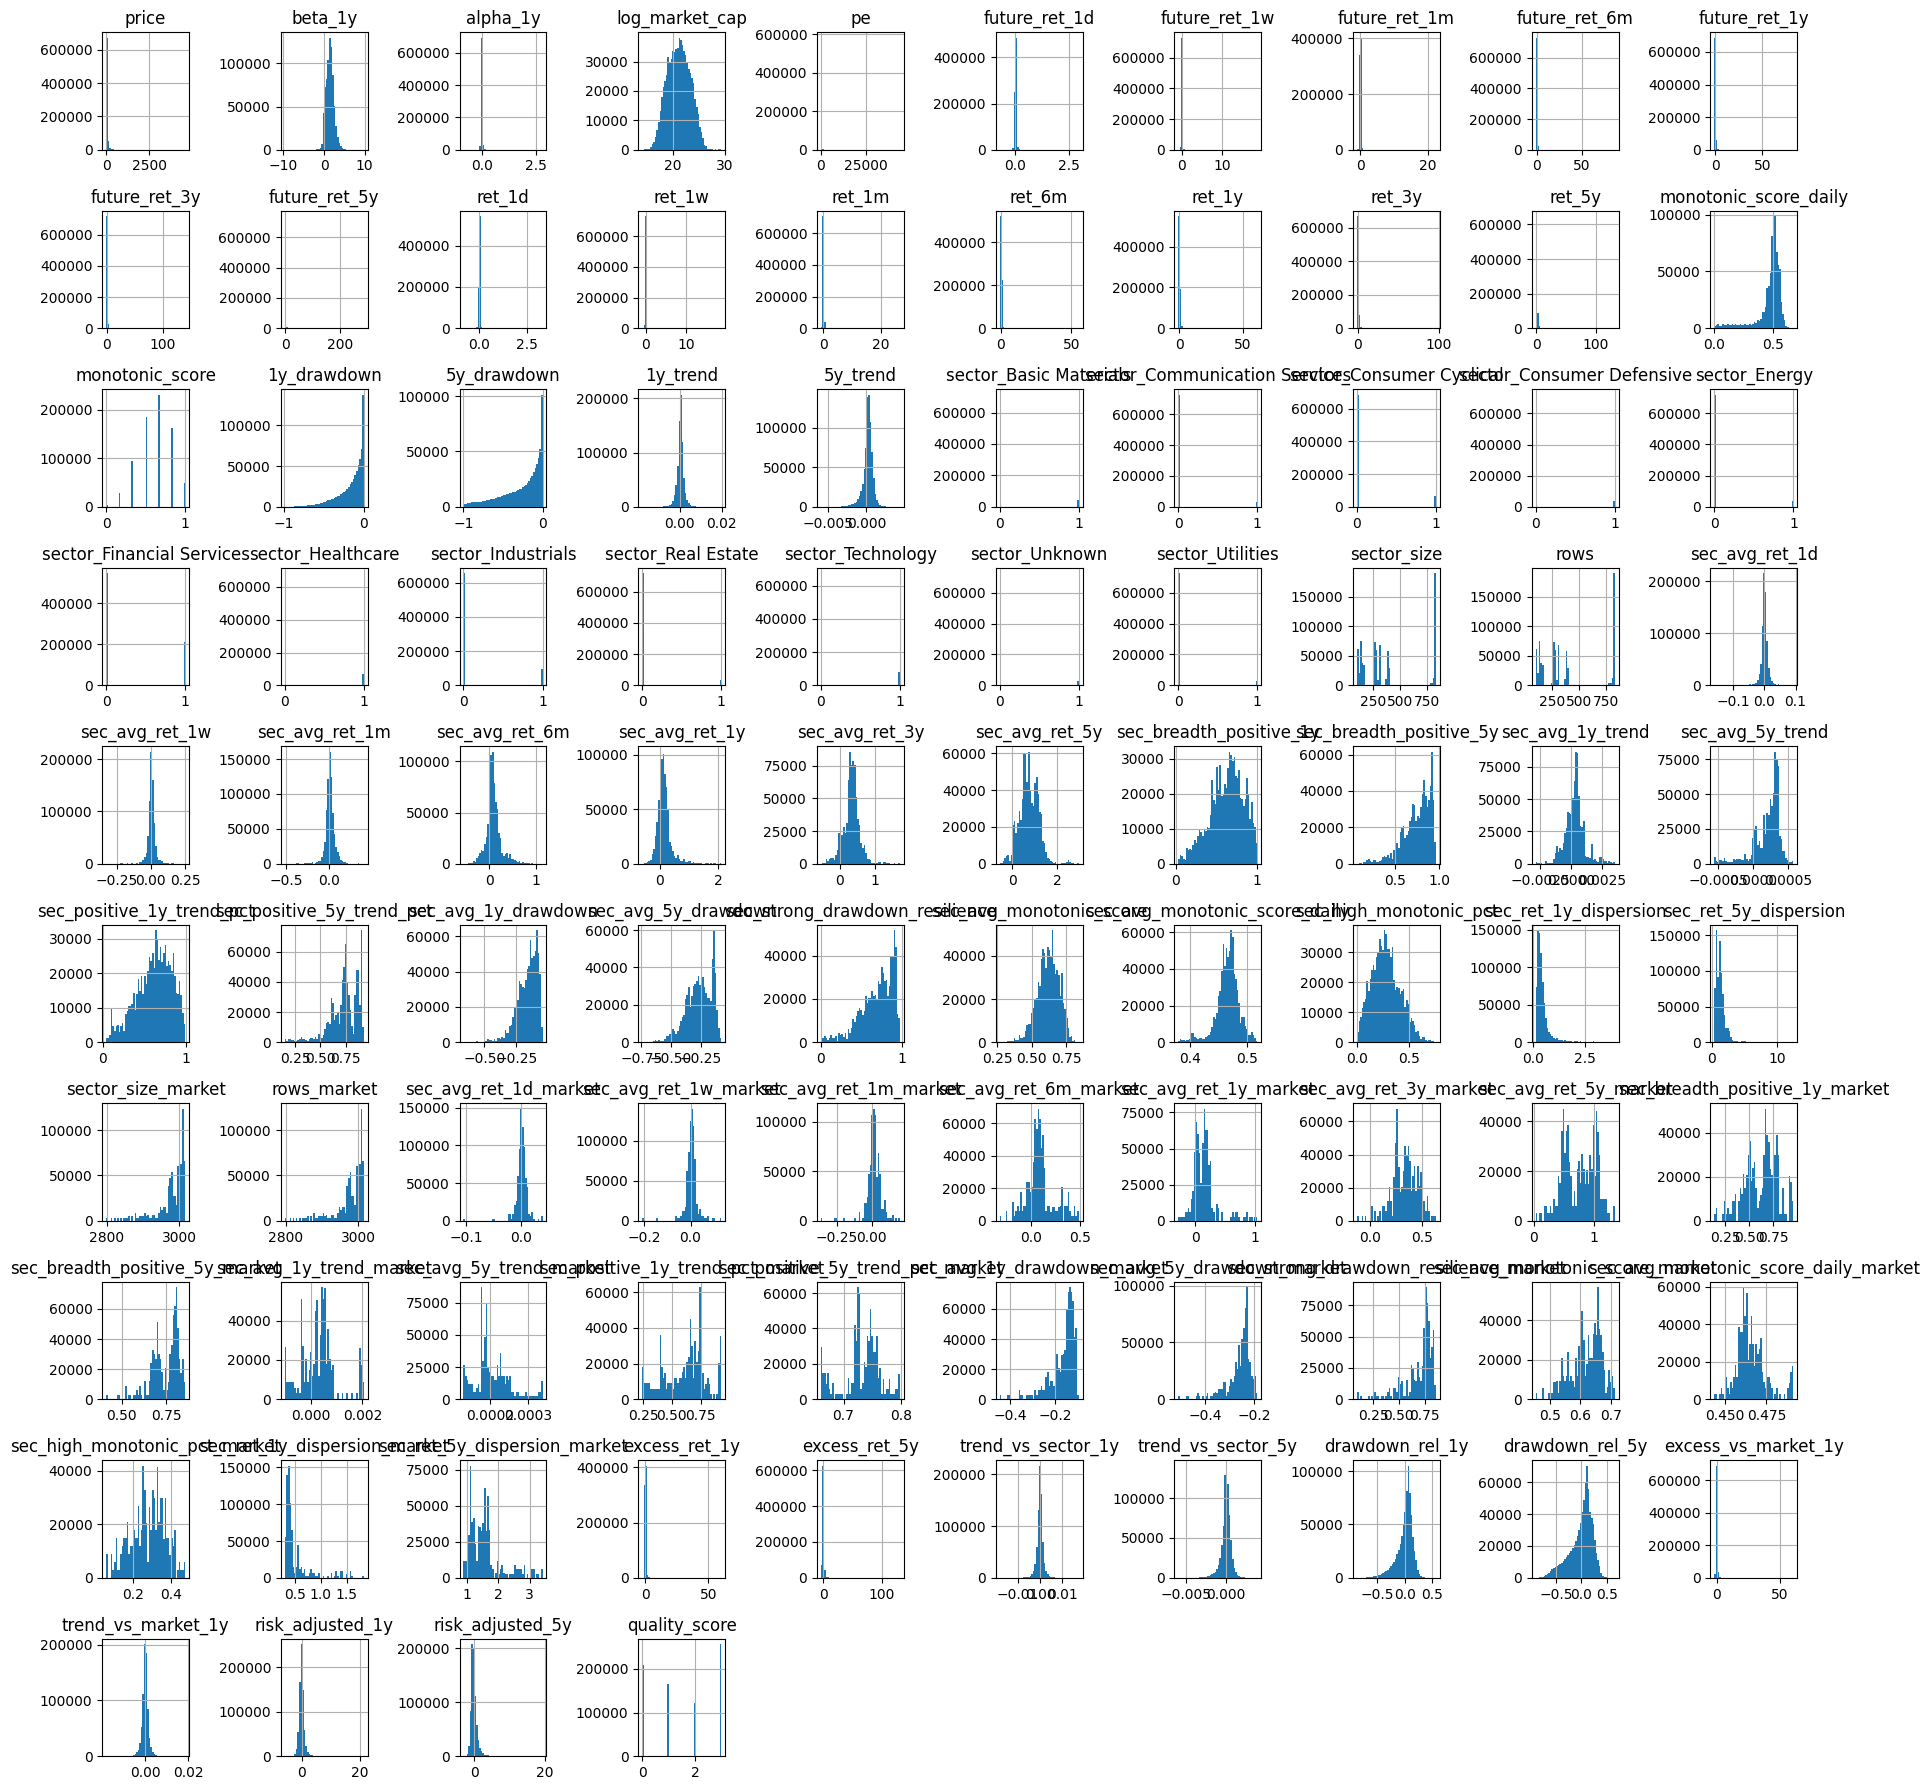

In [40]:
# Distribution Plot

import matplotlib.pyplot as plt

numeric.hist(figsize=(18, 18), bins=50)
plt.tight_layout()

In [41]:
future_cols = [c for c in df.columns if c.startswith("future_ret_")]

df[future_cols].describe().T

for col in future_cols:
    print(col)
    print(df[col].describe())
    print("Less than -100%:", (df[col] < -1).sum())
    print("Greater than 1000%:", (df[col] > 10).sum())
    print()

future_ret_1d
count    752856.000000
mean          0.001183
std           0.030844
min          -0.738594
25%          -0.008122
50%           0.000000
75%           0.009715
max           2.936410
Name: future_ret_1d, dtype: float64
Less than -100%: 0
Greater than 1000%: 0

future_ret_1w
count    752856.000000
mean          0.004109
std           0.075190
min          -0.895606
25%          -0.018917
50%           0.001417
75%           0.024020
max          18.728261
Name: future_ret_1w, dtype: float64
Less than -100%: 0
Greater than 1000%: 2

future_ret_1m
count    752856.000000
mean          0.016042
std           0.145142
min          -0.929595
25%          -0.036645
50%           0.009747
75%           0.059018
max          22.393944
Name: future_ret_1m, dtype: float64
Less than -100%: 0
Greater than 1000%: 6

future_ret_6m
count    752856.000000
mean          0.090102
std           0.435180
min          -0.974843
25%          -0.078237
50%           0.048087
75%           0.1889

In [42]:
future_cols = [c for c in df.columns if c.startswith("future_ret_")]

for col in future_cols:
    print("\n", col)

    extreme = df.nlargest(5, col)[
        ["ticker", "date", "price", col]
    ]

    print(extreme)


 future_ret_1d
       ticker       date   price  future_ret_1d
34069    AIRT 2020-12-23    9.75       2.936410
79854    UONE 2020-06-12   18.40       2.554348
126770   ASTC 2018-06-18   58.50       2.261539
740704   BLNK 2018-05-04    1.48       1.729730
666567   IBIO 2020-02-26  165.00       1.636364

 future_ret_1w
       ticker       date       price  future_ret_1w
79854    UONE 2020-06-12   18.400000      18.728261
314125   CHRD 2020-02-26    1.011891      18.696968
411368    GBR 2018-06-25    1.340000       5.641791
666567   IBIO 2020-02-26  165.000000       5.545455
73866    CARV 2020-06-12    1.990000       5.130653

 future_ret_1m
       ticker       date      price  future_ret_1m
314125   CHRD 2020-02-26   1.011891      22.393944
314124   CHRD 2020-02-19   1.336922      16.862392
314123   CHRD 2020-02-11   1.367586      15.394618
79851    UONE 2020-05-21  12.200000      14.868853
314122   CHRD 2020-02-04   1.361453      14.369368

 future_ret_6m
       ticker       date     p